# Calibrate MWR to observed landslide runout
#### Calibrate MWR to the Cascade Mountains 2022 landslide using the MWR calibrator utility

In 2022, the upper edge of the Cascades Mountain 2009 landslide scar enlarged, forming a new landslide. This second event was smaller than the 2009 event, but still moderate in size (initial landslide volume = 22,000 $m^3$). Runout of the second event was largely confined to a narrow channel along the center of the 2009 landslide runout path. Roughly 19% of the total mobilized volume (initial landslide + erosion) was derived from erosion during the runout.

<div align="center">
    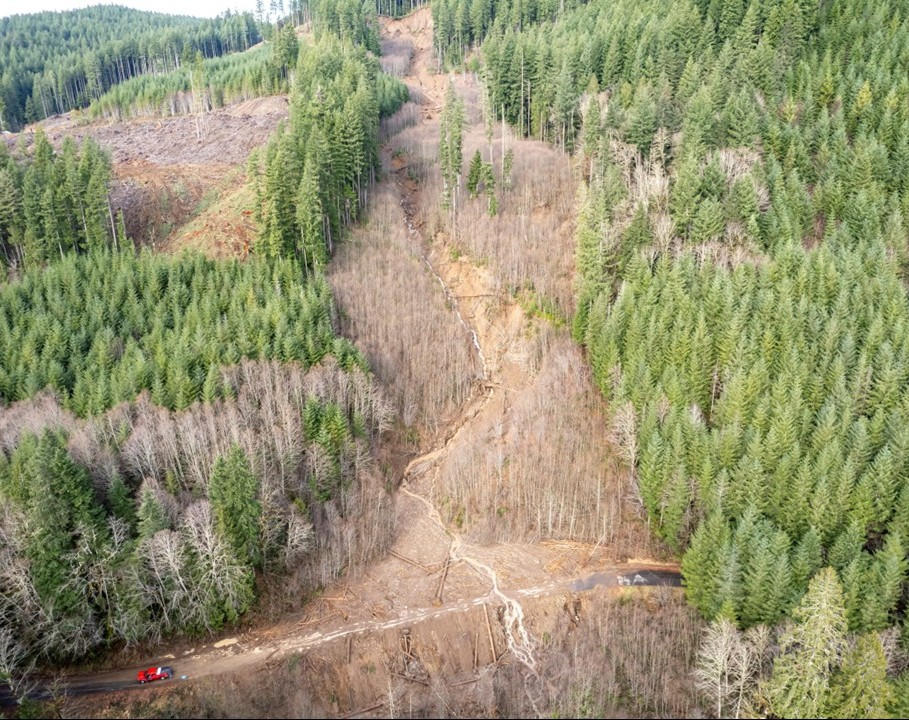
</div>

The runout both eroded and aggraded the hillslope surface. Areas of erosion tended to be over steep, convergent terrain while areas of deposition occured on gentler, unconfined terrain. 

<div align="center">
    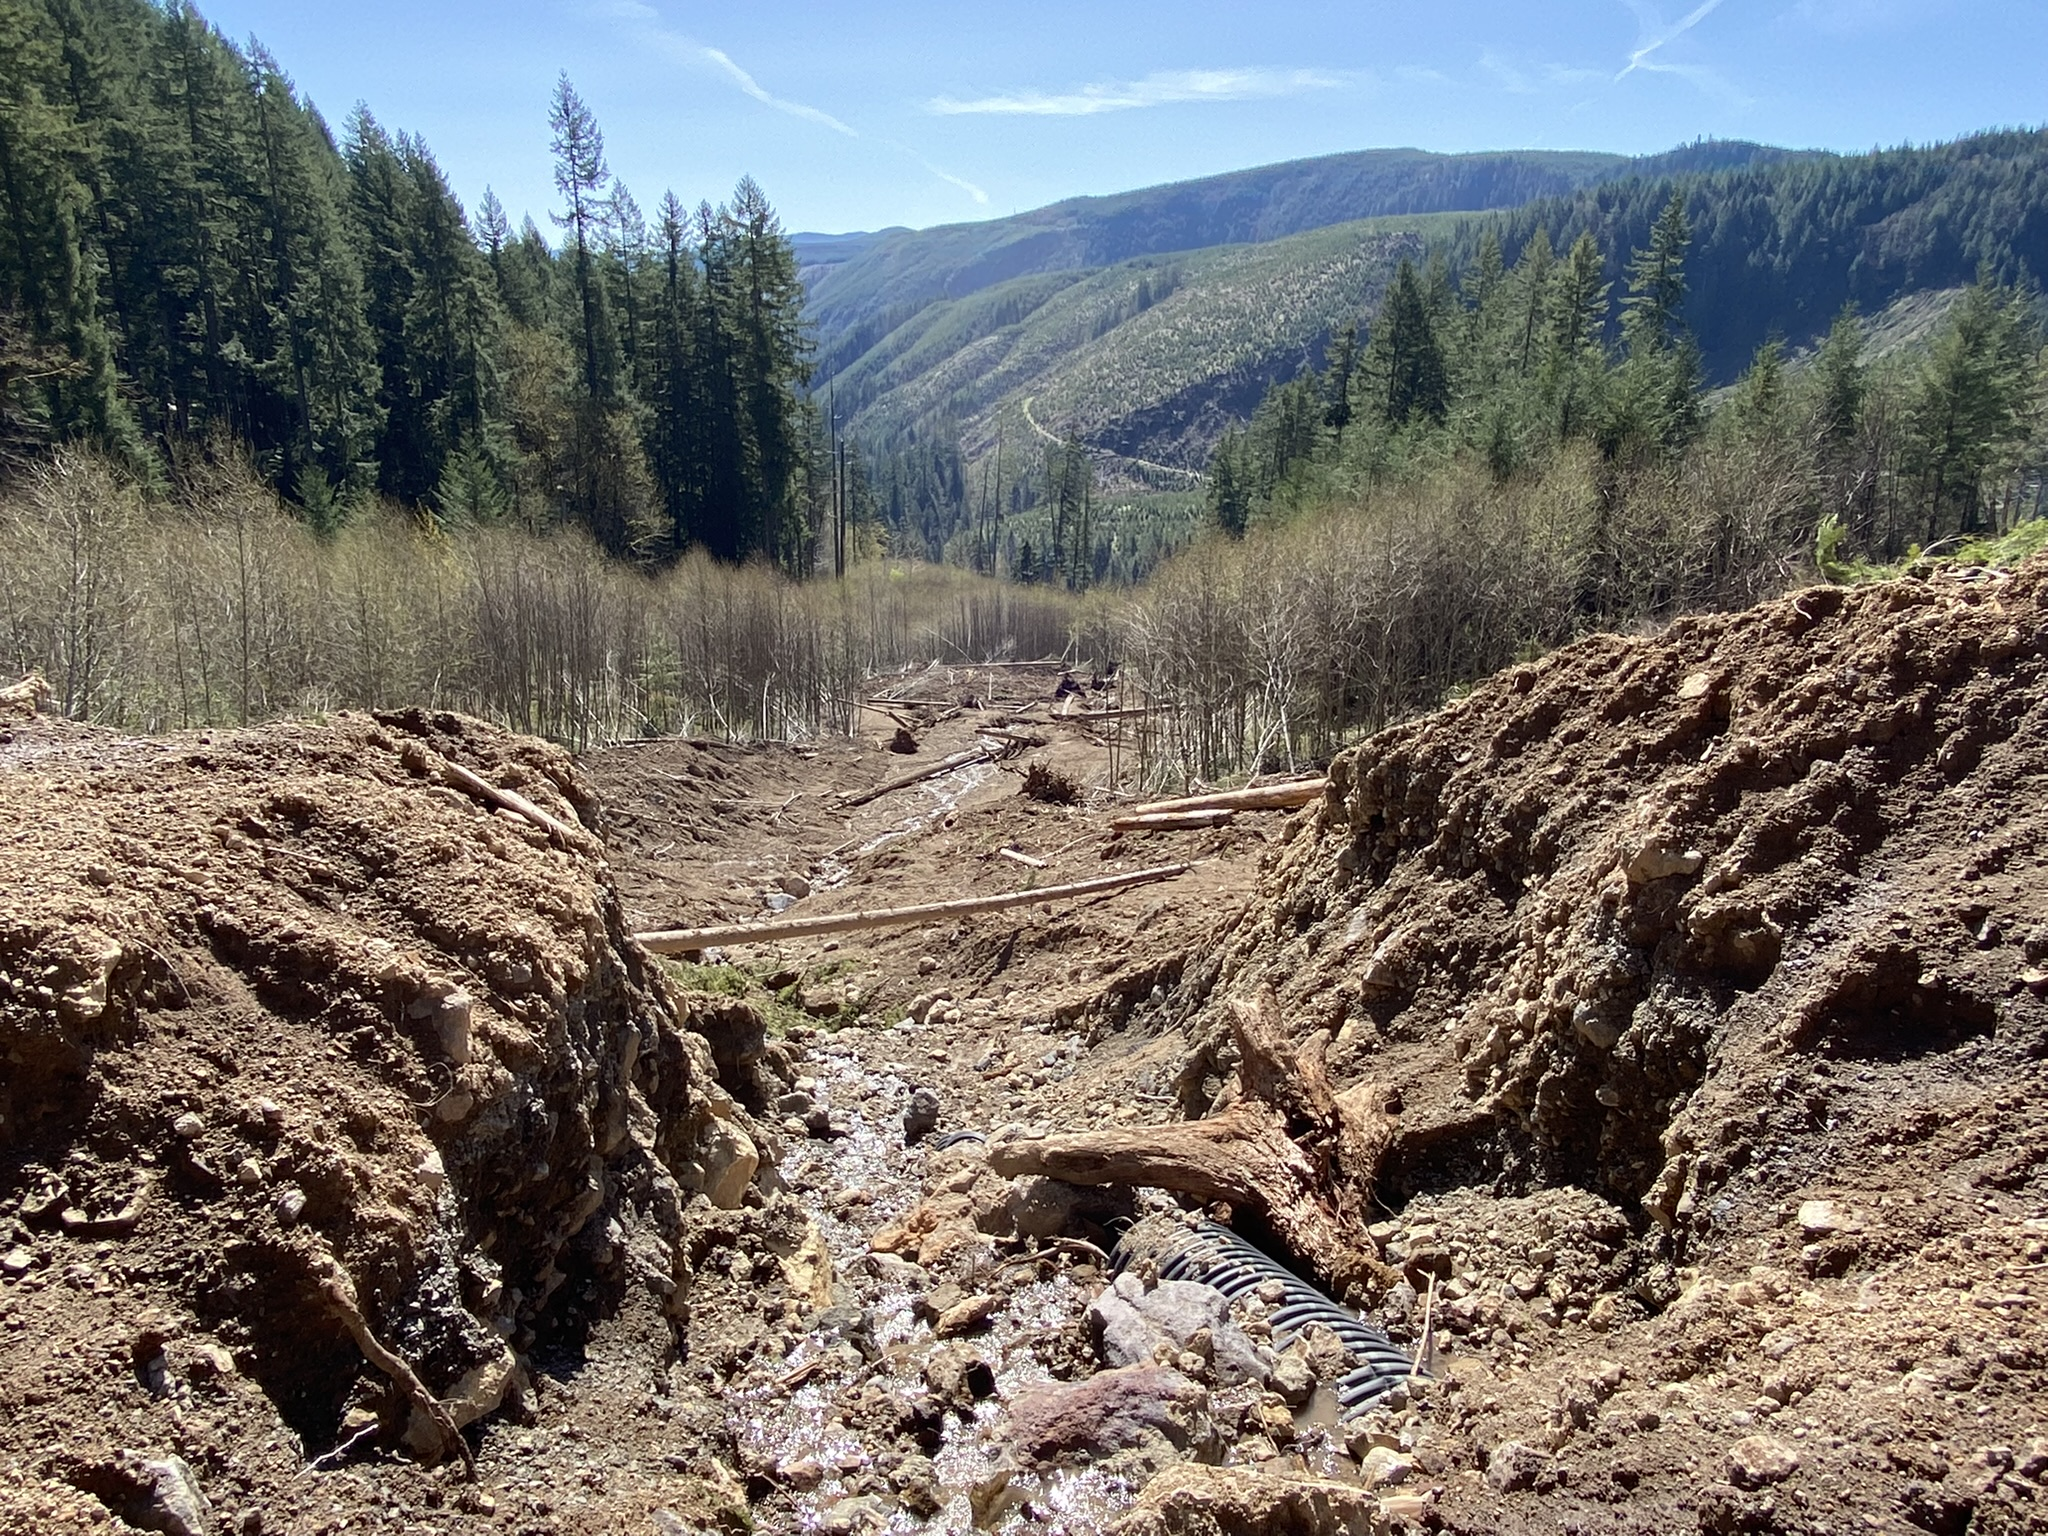
</div> 

MWR can be parameterized to mimic this runout behavior behavior. While some of the parameters that control its behavior can be inferred from the field, others may need to be determined through calibration. The MWR Calibrator utility automates the tuning process. In this tutorial, you will calibrate MWR to replicate runout behavior of the 2022 Cascade Mountains landslide using the MWR Calibrator utility.

## Calibrator overview

The MWR Calibrator utility uses an adaptive Bayesian Markov chain Monte Carlo (MCMC) algorithm to determine (1) a single set of parameters that best match MWR output to an observed landslide runout dataset and (2) posterior parameter probability distribution functions (PDFs). The observed runout dataset can consist of a single landslide or multiple landslides. To use the calibration utility, the user provides an initial (prior) guess of the parameter values and their respective PDFs that calibrate the MWR to a specific site. Then, the calibration utility randomly selects a set of trial parameter values (Λ) from the prior PDFs and runs MWR using Λ. Once the model has completed the run, the algorithm evaluates the posterior likelihood of the parameter set (L(Λ)) as the product of model ability to replicate observed runout (described below) and the prior likelihood of the parameter set.

<div align="center">
    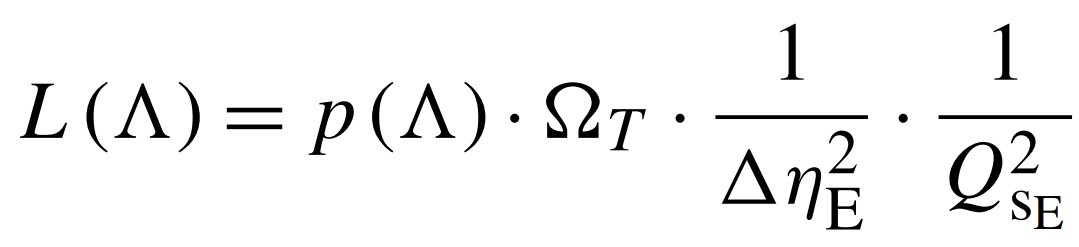
</div>   

 <!-- Links -->
[coz]: https://www.sciencedirect.com/science/article/abs/pii/S0022169413008329e
[esurf]:https://esurf.copernicus.org/articles/12/1165/2024/

Where $Ω_T$ is an index for evaluating model planimetric fit. $∆η_E$ is the volumetric error of the modeled
topographic change ($∆η$) over the entire model domain normalized by the observed total mobilized volume (initial landslide
body + erosion volume). The index $Q_{sE}$ is the mean error in cumulative sediment transport ($Q_s$) along the modeled runout path
normalized by the observed mean cumulative flow. Details on each metric included in the likelihood function are described in Section 3 of [Keck et al. (2024)][esurf].

After the first $L(Λ)$ has been determined, the calibration utility selects a new set of parameters $(Λ_{t+1})$ by jumping some distance from each parameter in Λ space. Depending on the value of $L(Λ_{t+1})$, the algorithm either stays at $Λ$ or moves to $Λ_{t+1}$. This Markov process is repeated a user-specified number of times. The jump direction is random, but the algorithm is adaptive because the jump distance changes depending on whether  a move occurs more than a user-specified threshold value. For a detailed description of the algorithm see [Coz et al. (2014)][coz]. After many jumps, this process produces a unique sampling pattern whose density can be used to estimate the probabilitly distribution of each sampled parameter. Below, an example is shown when $S_c$ and $qs_c$ are used as calibration parameters. The plot to the left shows where the MCMC algorithm sampled the $S_c$ - $qs_c$ parameter space and the two histograms on the right show the resulting parameter value distributions.

<div align="center">
    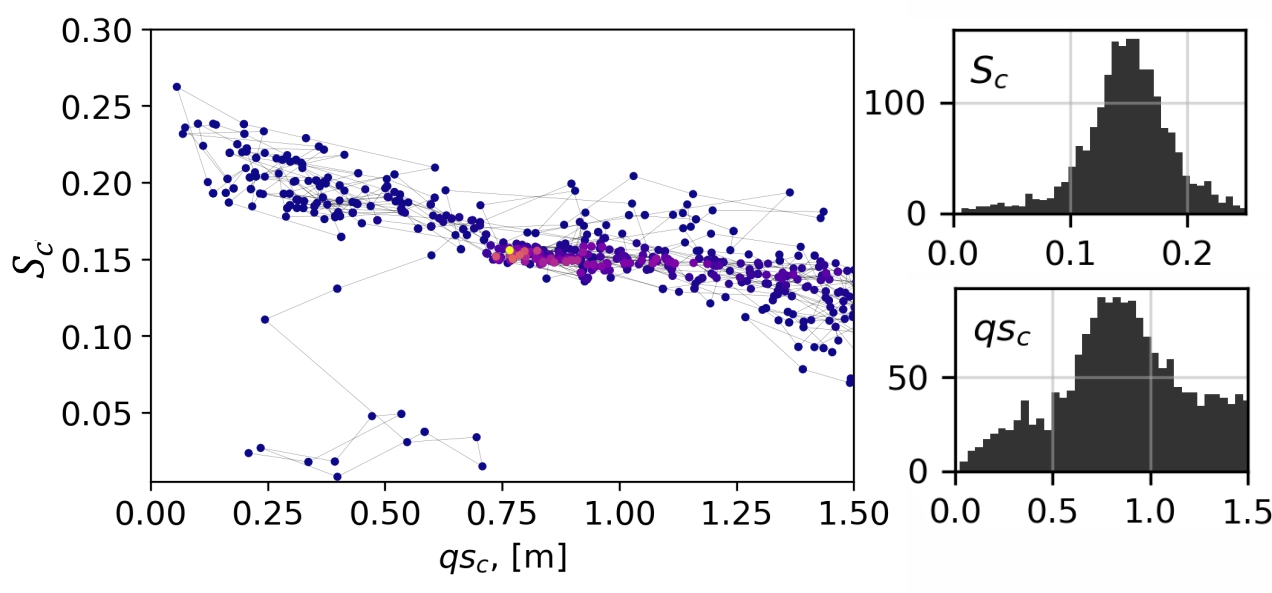
</div>

**1. Now that you are familiar with the calibrator utility apporoach, lets use it to calibrate MWR to observed landslide runout at the Cascade Mountains, 2022 site. To begin, first import  packages and components necessary to load MWR inputs, run MWR and visualize model results.**

In [ ]:
## import plotting tools
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
from IPython.display import HTML

# import pandas and numpy
import pandas as pd
import numpy as np

## import necessary landlab components
from landlab import RasterModelGrid
from landlab.components import(FlowAccumulator,
                                FlowDirectorD8, 
                                FlowDirectorMFD, 
                                DepressionFinderAndRouter)

#from landlab.components.mass_wasting_runout import MassWastingRunout # use this if you don't have a copy of mass_wasting_runout_vectorized
from mass_wasting_runout_vectorized import MassWastingRunout

from MWR_calibrator import (MWR_Calibrator,
                            profile_distance,
                            profile_plot,
                            define_profile_nodes,
                            view_profile_nodes,
                            plot_MCMC_jumps)

## import landlab plotting functionality
from landlab import imshow_grid_at_node

## import esri ascii read function
from landlab.io import esri_ascii

**2. In this implementation of MWR, we we will specify erosion coeficient k and erosion exponent f and let the calibrator utility find the critical slope ($S_c$) and flux ($q_c$) parameters.**

In [ ]:
# MWR Model parameters, determined from field and DoD
k = 0.0337443
typical_flow_thickness_of_erosion_zone = 2  # m
typical_slope_of_erosion_zone = 0.25
max_flow_depth_observed_in_field = 5  # m
Dp = 0.316  # m
# regolith and runout material attributes that will be tracked
tracked_attributes = ["particle__diameter"]

**3. The calibrator needs the mininmum, maximum and starting value of each calibration parameter. The minimum and maximum values will be used to parameterize the prior PDF of each parameter. The prior PDF can be uniform or normal. The default is normal. Other key calibrator parameters include the number of MCMC iterations. See comments next to each parameter for explanation**

In [ ]:
# MWR calibrator inputs
# define the prior estimate of the each parameter's distribution
# this is defined as a dictionary. Each key is an adjustable MWR parameter.
# Currently, adjustable parameters include: qsc, k, slpc, landslide_thickness_uniform, 
# soil_thickness_uniform, landslide_thickness_multiplier, soil_thickness_multiplier
# here we will adjust qsc and slpc
params = {'qsc':[0.01,1.75,0.3],
          'slpc':[0.005, 0.3, 0.03]}

# parameters that control behvior of the MCMC algorithm 
max_number_of_runs = 200 # number of times MCMC algorithm will iteratively run the model
# Number of iterations the MCMC algorithm jumps before computing the acceptance ratio and comparing to
# the minimum and maximum acceptance ratio thresholds. If the acceptance ratio is less than or more than 
# the thresholds (alpha_min and alpha_max), the jumpsize is adjusted. 
N_cycles = 100
alpha_max = 0.7 # maximum acceptance rate. If the acceptance rate is above this, the jump size is increased.
alpha_min = 0.3 # minimum acceptance rate. If the acceptance rate is below this the jumps size is decreased. 
# paramter that controls the MCMC jump size. The MCMC jump size is randomly determined from
# a normal distribution centered on the selected parameter value from the last MCMC iteration
# with a standard deviation defined as jump_size*(max parameter value - min parameter value).
jump_size = 0.09 

# elevation range used to evalute Q_s profile. Use these parameters to control which part of the observed DoD are used to calibrate MWR. 
el_l = 230
el_h = 430

**4. Next, define the initial model terrain and lanslide location and depth.**

To initiate MWR, the user needs to provide an initial DEM, a regolith depth map and the location and depth of the mass wasting source material (e.g., landslide body). In this example, the required inputs have been prepared using an external GIS system. The initial DEM was created after the 2009 landslide but before the 2021 enlargement. Regolith depth is assumed uniform and equal to 1.2 meters. The depth of the landslide was estimated by subtracting a DEM recorded after the 2021 failure from the initial DEM. The landslide polygon was mapped from airphotos of the 2021 landslide and converted to a gridded representation. The number of rows, number of columns and grid size (10 meter) of each input is the same and all are loaded as fields onto a Landlab raster model grid. Below we load each and add them as fields to a raster model grid. We also load a high-resolution hillshade of the model domain that will be used for visualizing model results.

In [ ]:
# GIS inputs needed run MWR and MWR calibrator
DEM_pre = "inputs/pre_runout_DEM.asc" # DEM of hillslope before the landslide occured
DEM_pre_hs = "inputs/pre_runout_DEM_hillshade.asc"  # high (2-meter resolution) DEM, used for plots only, not used in model
lsnodes = "inputs/landslide_polygon.asc"  # nodes within the mapped landslide
DoD_o = "inputs/DEM_of_Difference.asc"  # observed DEM of Difference
ls_depth = "inputs/landslide_depth.asc"  # measured depth at each node

#%% load inputs


# dem
with open(DEM_pre) as fp:
    mg = esri_ascii.load(fp, name="topographic__elevation", at="node")
z = mg.at_node["topographic__elevation"]

# ls nodes
with open(lsnodes) as fp:
    esri_ascii.load(fp, name="mass__wasting_id", at="node", out=mg)
mg.at_node["mass__wasting_id"] = mg.at_node["mass__wasting_id"].astype(int)

# observed DoD
with open(DoD_o) as fp:
    esri_ascii.load(fp, name="DoD_o", at="node", out=mg)

# change null values to zero
mg.at_node["DoD_o"][mg.at_node["DoD_o"] == -9999] = 0

# create a modeled DoD field, to be updated later to show animation of modeled DoD
mg.at_node["DoD_m"] = np.zeros(mg.number_of_nodes)

# soil depth
# here using uniform depth of 1.2 meters
depth = np.ones(mg.number_of_nodes) * 1.2
mg.add_field("soil__thickness", depth, at="node")

# set landslide thickness (depth) equal to measured depth from DEM of Difference
with open(ls_depth) as fp:
    esri_ascii.load(fp, name="ls_depth", at="node", out=mg)

lsd = mg.at_node.pop("ls_depth")
lsd = lsd[lsd != -9999]
mg.at_node["soil__thickness"][mg.at_node["mass__wasting_id"] == 1] =  lsd

# high res hillshade for plot background
with open(DEM_pre_hs) as fp:
    mg_hs = esri_ascii.load(fp, name="hillshade_arc", at="node")
mg_hs.at_node["hillshade_arc"][mg_hs.at_node["hillshade_arc"] == -9999] = np.nan


# landlab built in hillshade
mg.at_node['hillshade'] = mg.calc_hillshade_at_node(elevs=z, alt=37., az=210.)


# finds lowest point in dem and sets it as an open node

mg.set_watershed_boundary_condition(z)

# add particle diameter
# representative grain size of regolith
mg.at_node["particle__diameter"] = np.ones(len(mg.node_x)) * Dp

# flow accumulater to get contributing area to each grid cell. We initially use the FlowDirectorD8 option
# to visualize topographic slope but will replace the flow router with the MFD option later in this notebook
# because MWR uses the multi-directional slope.
fa = FlowAccumulator(mg, "topographic__elevation", flow_director="FlowDirectorD8")
fa.run_one_step()

# fill depressions to correct surface area determination
df_4 = DepressionFinderAndRouter(mg)
df_4.map_depressions()

# save a copy of the initial elevation for dem differencing
_ = mg.add_field(
    "topographic__initial_elevation",
    mg.at_node["topographic__elevation"],
    at="node",
    copy=True,
)

# multiflow direction for MWRu
# need to delete d8 flow direction
mg.delete_field(loc = 'node', name = 'flow__sink_flag')
mg.delete_field(loc = 'node', name = 'flow__link_to_receiver_node')
mg.delete_field(loc = 'node', name = 'flow__receiver_node')
mg.delete_field(loc = 'node', name = 'topographic__steepest_slope')
# run flow director, add slope and receiving node fields
fd = FlowDirectorMFD(mg, diagonals=True,
                      partition_method = 'slope')
fd.run_one_step()

**5. Before we instantiate and run the model, lets visualize some of the loaded inputs to get a feel for the landslide geometry relative to the terrain.**

First we need to define a few functions for visualizing model results.<br>
These functions are only included in this notebook for visualization and are not necessary to run the model.

In [ ]:
def plot_node_field_with_shaded_high_res_dem(
    mg,
    mg_hs,
    field,
    save_name=None,
    plot_name=None,
    figsize=(7, 7),
    cmap="terrain",
    fontsize=10,
    alpha=0.5,
    cbr=None,
    norm=None,
    allow_colorbar=True,
    colorbar_label=None,
    var_name=None,
    var_units=None,
    domain_buffer=0,
    **kwds,
):
    if plot_name is None:
        plt.figure(field, figsize=figsize)
    else:
        plt.figure(plot_name, figsize=figsize)

    mg_hs.imshow(
        "hillshade_arc",
        cmap="Greys_r",
        grid_units=("coordinates", "coordinates"),
        shrink=0.75,
        var_name=None,
        var_units=None,
        output=None,
        allow_colorbar=False,
        color_for_background="white",
        color_for_closed="white",
        limits=(0, 360),
    )
    mg.imshow(
        field,
        cmap=cmap,
        grid_units=("coordinates", "coordinates"),
        shrink=0.75,
        var_name=var_name,
        var_units=var_units,
        alpha=alpha,
        output=None,
        color_for_closed=None,
        color_for_background=None,
        norm=norm,
        allow_colorbar=allow_colorbar,
        colorbar_label=colorbar_label,
    )

    plt.xlim(
        [
            mg.x_of_node[mg.core_nodes].min() - 20,
            mg.x_of_node[mg.core_nodes].max() + domain_buffer,
        ]
    )
    plt.ylim(
        [
            mg.y_of_node[mg.core_nodes].min() - 20,
            mg.y_of_node[mg.core_nodes].max() + domain_buffer,
        ]
    )

    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    if cbr is None:
        r_values = mg.at_node[field][mg.core_nodes]
        plt.clim(r_values.min(), r_values.max())
    else:
        plt.clim(cbr[0], cbr[1])

    if save_name is not None:
        plt.savefig(save_name + ".png", dpi=300, bbox_inches="tight")



In [ ]:
#The 2022 Cascade Mountain landslide source area
plot_node_field_with_shaded_high_res_dem(mg, mg_hs = mg_hs, field = 'mass__wasting_id',plot_name = 'high_res',cmap = 'Reds', fontsize = 10,alpha = .5)

In [ ]:
#The 2022 Cascade Mountain landslide observed DoD. 
#The Calibrator Utilty will try to find the MWR parameter values that match the modeled DoD to the osberved DoD
plot_node_field_with_shaded_high_res_dem(mg, mg_hs=mg_hs, field="DoD_o", cmap="bwr", alpha=0.5, cbr=[-1, 1], fontsize=7)

**6. Now, instantiate MWR using the model parameters defined above**

In [ ]:
MWR = MassWastingRunout(
    grid=mg,
    erosion_coefficient=k,
    tracked_attributes=tracked_attributes,
    save=True,
    typical_flow_thickness_of_erosion_zone=typical_flow_thickness_of_erosion_zone,
    typical_slope_of_erosion_zone=typical_slope_of_erosion_zone,
    max_flow_depth_observed_in_field=max_flow_depth_observed_in_field,
)


**7. Next, define a profile over the expected runout path. This path will be used to determine Qs over the extent of the runout.**
As described above, the $Q_s$ metric represents cumulative sedimant transport past a point along the runout path of the landslide and is computed by summing the total eroded volume upslope of a point on the runout path as:


<div align="center">
    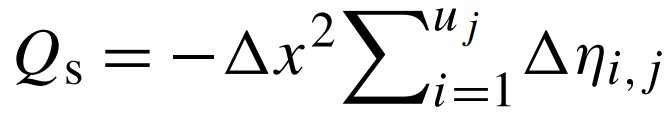
</div>  

where $∆η_{i,j}$ is the topographic change at the ith nodelocated above the elevation of node j , and $u_j$ is the total number of nodes located above node j. $Q_s$ is computed for both the observed and modeled runout ($Qs_O$ and $Qs_M$, respectively). The cumulative error along a profile of $r$ nodes ($Q_{sE}$), which is very sensitive to different parameterizations of MWR, is defined as: 

<div align="center">
    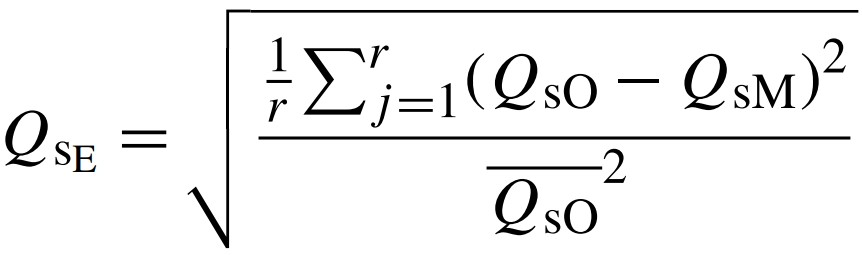
</div>  

<em> In this step, you can use a pre-defined profile of the $r$ nodes or you can draw a profile (set draw_profile_nodes to True). If you draw your own provile, follow the prompted messages.**

In [ ]:
draw_profile_nodes = False

if draw_profile_nodes: # draw your own profile
    
    %matplotlib qt 
    # the function below opens a seperate window that shows the shaded DEM and the landslide location. 
    # Click once on the window to begin (ignore error messages), then follow the directions below
    runout_profile_nodes, runout_profile_dist, Lxy = define_profile_nodes(mg)
    %matplotlib inline
    print(f"runout_profile_nodes: \n {runout_profile_nodes}")
    print(f"runout_profile_dist: \n {runout_profile_dist}")

else: # use predefined profile
    
    runout_profile_nodes = np.array([7222, 7223, 7143, 7063, 6984, 6904, 6824, 6825, 6745, 6665, 6666,
       6586, 6506, 6426, 6427, 6347, 6267, 6268, 6188, 6108, 6028, 5948,
       5868, 5788, 5789, 5709, 5629, 5549, 5469, 5470, 5390, 5391, 5311,
       5312, 5232, 5233, 5153, 5073, 5074, 4994, 4914, 4834, 4754, 4755,
       4675, 4595, 4515, 4435, 4355, 4275, 4195, 4196, 4116, 4036, 3956,
       3876, 3796, 3716, 3636, 3556, 3476, 3477, 3397, 3317, 3237, 3238,
       3158, 3078, 2998, 2999, 2919, 2839, 2759, 2760, 2680, 2600, 2601,
       2521, 2522, 2442, 2362, 2363, 2283, 2284, 2204, 2124, 2125, 2045,
       1965, 1966, 1886, 1806, 1726, 1646, 1566, 1486, 1406, 1326, 1246,
       1247, 1167, 1087, 1007, 1008,  928,  848,  768,  769,  689,  609,
        529,  530,  450]) 
    runout_profile_dist = np.array([0.  ,   0.76,   4.82,  15.74,  26.52,  37.44,  48.22,  52.28,
        59.14,  69.92,  78.05,  80.84,  91.62, 102.54, 103.81, 113.32,
       126.78, 132.98, 134.48, 144.69, 154.79, 165.  , 175.1 , 185.21,
       192.11, 195.41, 205.52, 215.72, 226.73, 232.65, 239.59, 246.74,
       253.74, 260.89, 267.83, 280.47, 281.64, 292.04, 302.01, 302.51,
       312.9 , 323.38, 333.77, 337.03, 344.24, 364.18, 365.12, 375.07,
       385.14, 395.09, 405.16, 410.43, 415.11, 425.18, 435.13, 445.2 ,
       455.15, 465.21, 481.13, 485.4 , 495.84, 503.03, 506.34, 516.84,
       527.34, 537.22, 537.8 , 548.53, 559.2 , 565.08, 569.86, 580.53,
       591.19, 601.79, 601.86, 613.79, 615.02, 625.72, 633.31, 637.65,
       649.58, 651.67, 661.5 , 669.96, 674.01, 684.62, 691.81, 695.75,
       706.88, 714.7 , 717.95, 731.92, 739.37, 749.38, 759.39, 769.4 ,
       783.99, 789.7 , 800.27, 805.14, 810.75, 821.32, 831.89, 836.76,
       842.37, 852.94, 863.52, 868.38, 877.45, 884.6 , 895.29, 897.71,
       905.98])

**8. Lets take a look a the profile location and pre- and post-event topographic change:**

In [ ]:
#%% look at the profile nodes
# plan view
mg.at_node['long_profile'] = np.zeros(mg.number_of_nodes)
mg.at_node['long_profile'][runout_profile_nodes] = 1
plt.figure(figsize = (8,8))
plot_node_field_with_shaded_high_res_dem(mg, mg_hs=mg_hs, field="long_profile", cmap="Greys", alpha=0.5, cbr=[0, 1], fontsize=7)
plt.title('long profile location')
# profile
profile_plot(mg, runout_profile_nodes, runout_profile_dist, aspect = 2,figsize = (12,5), fs = 16)

**9. Now that you have defined a profile from which sediment transport patterns along the runout path will be evaluted, it's time to instantiate the Calibrator Utility...**

In [ ]:
#%% instantiate the calibration class
calibrator = MWR_Calibrator(MWR, 
                            params, 
                            el_l, 
                            el_h, 
                            runout_profile_nodes, # give the calibrator utility the profile nodes and distances
                            runout_profile_dist,
                            N_cycles = N_cycles, # MCMC parameters specified above
                            prior_distribution = "uniform", 
                            jump_size = jump_size, 
                            alpha_max = alpha_max, 
                            alpha_min=alpha_min, 
                            plot_calibration_metrics = False, 
                            seed = 15, # set a seed if you want to compare different parameterizations of the MCMC algrorithm
                            show_progress = True # this will plot model results and the liklihood score, leave True for this exercies
                           )


**10. And run the Calibrator Utility!**

In [ ]:
#%% calibrate the model, progress will be printed for every 5th MCMC iteration 
parameters = calibrator(max_number_of_runs = max_number_of_runs)

**11. Once the Calibration Utility has finsished, plot the parameter and resulting likelihood values tested by the algorithm**

In [ ]:
results = calibrator.MCMC_stats
plot_MCMC_jumps(results, 'qsc', 'slpc')

**12. Finally, make an animation of the progression of the MCMC algorithm**

In [ ]:
parameter_1 = 'qsc'
parameter_2 = 'slpc'

plot_interval = 10 # plot every plot_interval-th frame - note if interval is too short, 
# animation may not include the entire modeled output

def get_values_xy(grid, field):
    # convert grid array to input for pcolormesh (from imshow_grid)
    values = grid.at_node[field]
    values = values.reshape(grid.shape)
    y = (
        np.arange(values.shape[0] + 1) * grid.dy
        - grid.dy * 0.5
        + grid.xy_of_lower_left[1]
    )
    x = (
        np.arange(values.shape[1] + 1) * grid.dx
        - grid.dx * 0.5
        + grid.xy_of_lower_left[0]
    )
    return x, y, values


# new plotting function
def color_mesh_vals_subplot(ax, clim=[-1, 1]):
    x, y, values = get_values_xy(mg, "DoD_m")
    myimage = ax.pcolormesh(x, y, values, vmin = clim[0], vmax = clim[1], cmap="bwr", alpha=0.5)
    myimage.set_rasterized(True)
    myimage.axes.set_aspect("equal")
    return myimage

# update function

def update_plot(frame_number, calibrator, myimage, line_o, line_m, results, jump_lines, sc):
    score = calibrator.MCMC_stats['selected_posterior'].iloc[frame_number]
    
    # DoD
    mg.at_node["DoD_m"] = (
        calibrator.DoD_m_dict[frame_number]
    )
    # myimage[0].set_array(mg.at_node["DoD_m"])
    myimage[0].remove()
    # myimage[0] = color_mesh_vals(clim=[-1, 1])
    myimage[0] = color_mesh_vals_subplot(ax3, clim=[-1, 1])
    plt.title(f"DoD_m, iteration {frame_number}, "+r'$L(\Lambda) = {}$'.format(np.round(score,decimals = 2)), fontsize = 8)

    # Qs
    observed = calibrator.mbLdf_o[calibrator.profile_metric] 
    modeled =  calibrator.trial_Qs_profiles[frame_number] 
    line_o.set_data(calibrator.mbLdf_o['runout_profile_distance'], observed)
    line_m.set_data(calibrator.mbLdf_o['runout_profile_distance'], modeled)

    # MCMC jump plot
    x = results['selected_value_{}'.format(parameter_1)].iloc[:frame_number+1], 
    y = results['selected_value_{}'.format(parameter_2)].iloc[:frame_number+1]
    jump_lines.set_data(x, y)
    z = results['candidate_posterior'].iloc[:frame_number+1]
    a = results['selected_value_{}'.format(parameter_1)].iloc[:frame_number+1].values
    b = results['selected_value_{}'.format(parameter_2)].iloc[:frame_number+1].values
    sc.set_offsets(np.array([a,b]).T)
    sc.set_array(z)
    print(f"\rPreparation of runout animation is {int(100*frame_number/(nmax-plot_interval+1))}% complete", end="")
    return myimage#, line_o, line_m, 


# prepare the first frame
fig = plt.figure(figsize=(7.7, 6))

# Define a 2x2 grid
# height_ratios=[1, 2] makes the bottom row twice as tall as the top
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[0.65, 1],
                       wspace=0.15, hspace=0.205, top=0.95, bottom=0.05, left=0.09, right=0.95)

ax1 = fig.add_subplot(gs[0, 0]) # Top Rectangular
ax2 = fig.add_subplot(gs[1, 0]) # Bottom Square 1
ax3 = fig.add_subplot(gs[:, 1]) # Bottom Square 2

# control aspect of bottom two plots
ax1.set_box_aspect(1)
ax2.set_box_aspect(1) 
ax3.set_box_aspect(1.55)

# add the data

# DoD
nmax = len(calibrator.DoD_m_dict.keys())
x, y, values = get_values_xy(mg_hs, "hillshade_arc")
myimage = ax3.pcolormesh(x, y, values, cmap="Greys_r", alpha=1)
myimage.set_rasterized(True)
myimage.axes.set_aspect("equal")
ax3.autoscale(tight=True)
ax3.xaxis.set_tick_params(labelbottom=False)
ax3.yaxis.set_tick_params(labelleft=False)
myimage = [color_mesh_vals_subplot(ax3, clim=[-1, 1])]


# Qs plot
observed = calibrator.mbLdf_o[calibrator.profile_metric] 
modeled =  calibrator.trial_Qs_profiles[0] 
line_o, = ax2.plot(calibrator.mbLdf_o['runout_profile_distance'], observed, label = 'observed')
line_m, = ax2.plot(calibrator.mbLdf_o['runout_profile_distance'], modeled, label = 'modeled')
ax2.tick_params(axis = 'both', which = 'major', labelsize = 6)
ax2.set_ylabel('Qs, $m^3$', fontsize = 6)
ax2.set_xlabel('distance from crown, m', fontsize = 6)
ax2.legend(loc = 'upper left', fontsize = 8)
ax2.set_title('Cumulative sediment transport, Qs $m^3$', fontsize = 8)


# MCMC jump plot
frame_number = 0
jump_lines, = ax1.plot(results['selected_value_{}'.format(parameter_1)][:frame_number+1], results['selected_value_{}'.format(parameter_2)][:frame_number+1], 
                  linestyle = '-', color = 'k',
                  alpha = 0.75, linewidth = 0.1,zorder=0)
z = results['candidate_posterior'][:frame_number+1]
sc = ax1.scatter(results['selected_value_{}'.format(parameter_1)][:frame_number+1], results['selected_value_{}'.format(parameter_2)][:frame_number+1], c=z, s=5, cmap="plasma", alpha = 1,zorder=10)

ax1.set_xlabel('{}'.format(parameter_1), fontsize = 6)
ax1.set_ylabel('{}'.format(parameter_2), fontsize = 6)
ax1.tick_params(axis = 'both', which = 'major', labelsize = 6)
cbar = fig.colorbar(sc, ax=ax1, fraction=0.046, pad=0.04)
ax1.set_xlim(calibrator.params[parameter_1][0], calibrator.params[parameter_1][1])
ax1.set_ylim(calibrator.params[parameter_2][0], calibrator.params[parameter_2][1])
ax1.set_title('parameter values tested by MCMC algorithm', fontsize = 8)
cbar.ax.tick_params(labelsize = 6)


animate = animation.FuncAnimation(
    fig,
    update_plot,
    np.arange(0,nmax,plot_interval),
    fargs=(calibrator, myimage, line_o, line_m, results, jump_lines, sc),
    blit=True,
    repeat=True,
    cache_frame_data=False,
)

HTML(animate.to_jshtml())